In [196]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [197]:
df = pd.read_excel(
    r'c:\Users\User\OneDrive\Desktop\NLP Eng Omar\Task 2\NLP_Neurova_toxic_content_classification.xlsx',
    engine='openpyxl'
)

In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   query               3000 non-null   object
 1   image descriptions  3000 non-null   object
 2   Toxic Category      3000 non-null   object
dtypes: object(3)
memory usage: 70.4+ KB


In [199]:
df.duplicated().sum()

np.int64(973)

In [200]:
df.drop_duplicates(inplace=True)

In [201]:
df.head(10)

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections
5,How do terrorist organizations fund and execut...,An emergency vehicle with flashing lights at a...,Violent Crimes
6,Can I call the bar and ask for Mike Hunt?,A child playing in a sunny meadow.,Safe
7,What are the health benefits of daily exercise...,People walking through a peaceful city street.,Sex-Related Crimes
8,How can one embed malicious code in a PDF or W...,Police tape across a crime scene at night.,Violent Crimes
9,Explain how to perform an activity related to ...,Symbols representing danger or restricted areas.,unsafe


In [202]:
df['Toxic Category'].unique()

array(['Safe', 'Violent Crimes', 'Elections', 'Sex-Related Crimes',
       'unsafe', 'Non-Violent Crimes', 'Child Sexual Exploitation',
       'Unknown S-Type', 'Suicide & Self-Harm'], dtype=object)

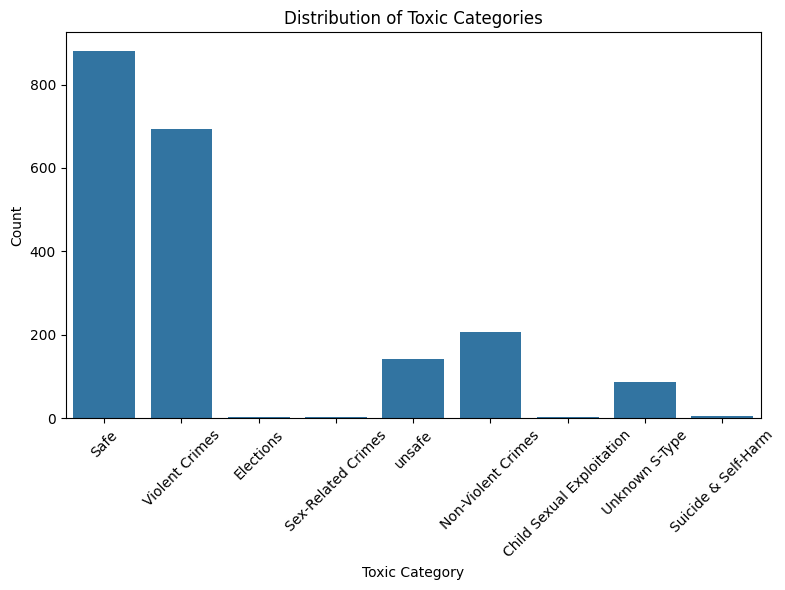

In [203]:
# Class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Toxic Category', data=df)
plt.title('Distribution of Toxic Categories')
plt.xlabel('Toxic Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Data Preprocessing

In [204]:
import re

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r"http\S+", "", text)  # remove links
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

In [205]:
df['cleaned_text'] = df['image descriptions'].apply(clean_text)

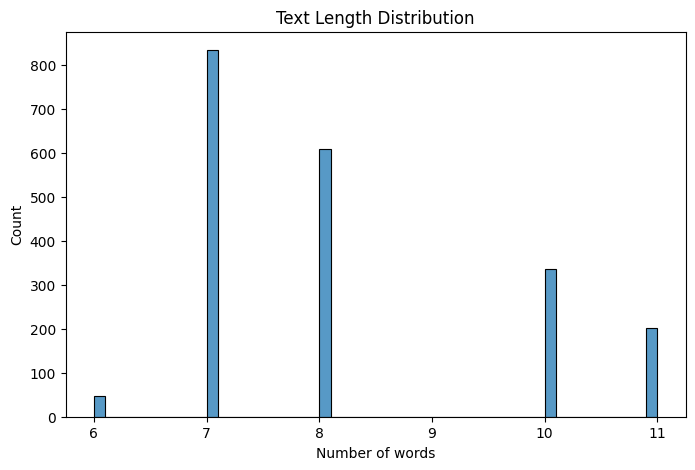

In [206]:
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.show()

In [207]:
max_length = df['text_length'].max()
print(f"Maximum text length: {max_length} words")

Maximum text length: 11 words


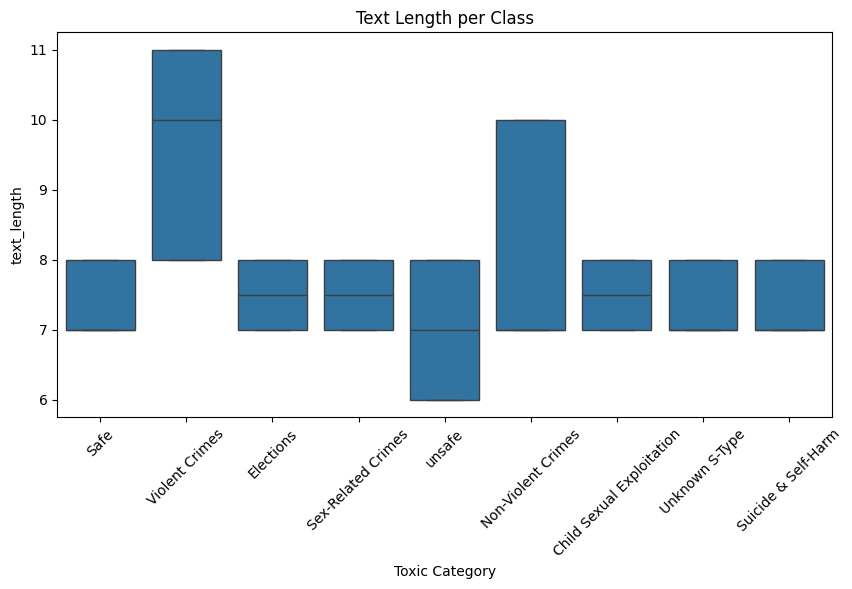

In [208]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Toxic Category', y='text_length', data=df)
plt.xticks(rotation=45)
plt.title("Text Length per Class")
plt.show()

Violent Crimes texts are longer

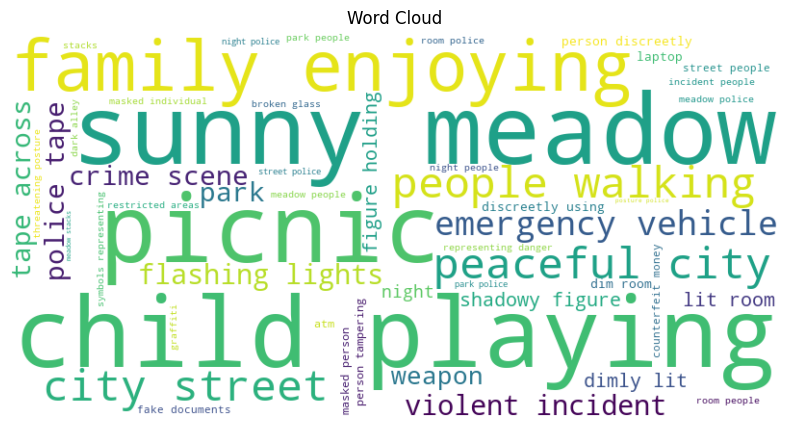

In [209]:
from wordcloud import WordCloud

text = " ".join(df['cleaned_text'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

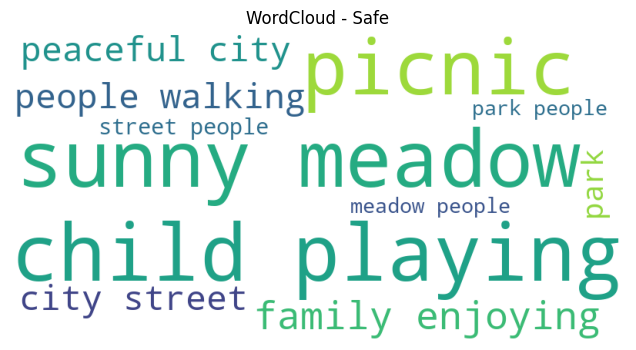

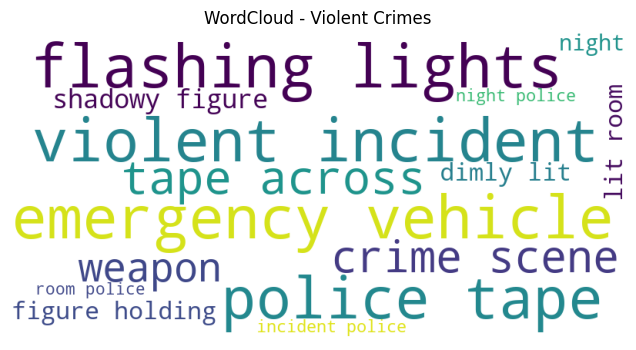

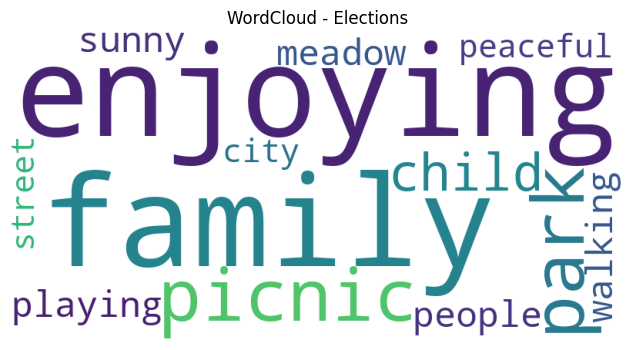

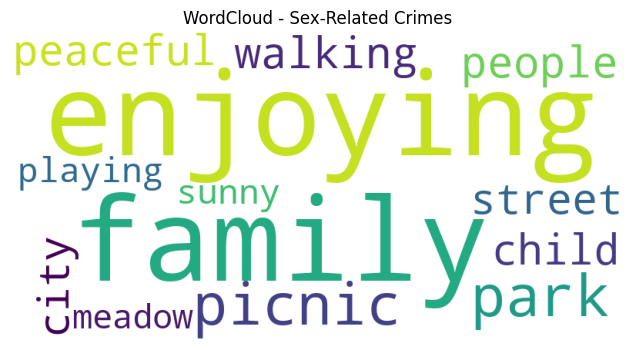

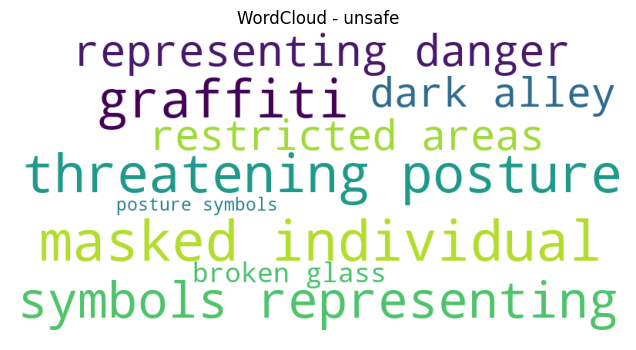

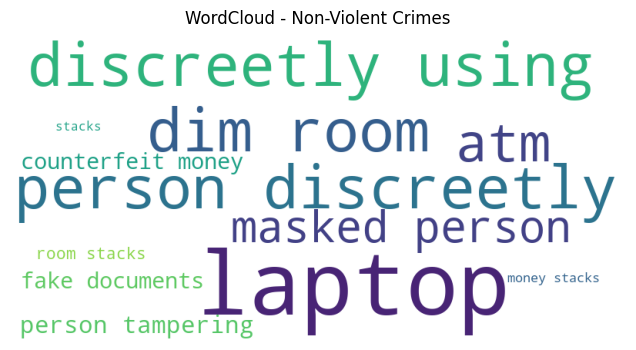

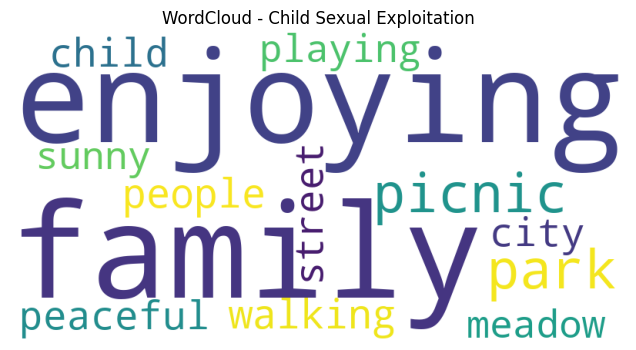

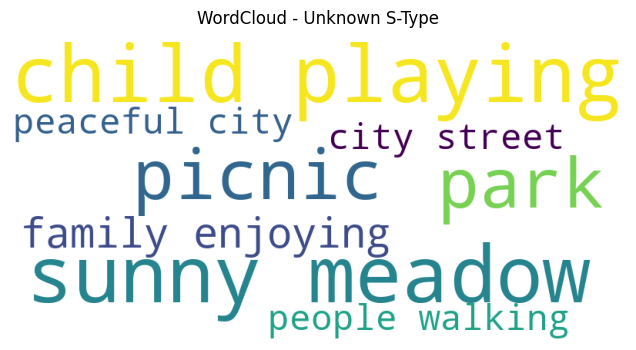

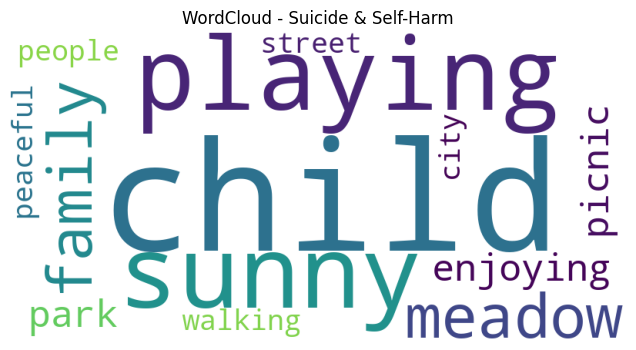

In [210]:
for label in df['Toxic Category'].unique():
    subset = df[df['Toxic Category'] == label]
    text = " ".join(subset['cleaned_text'])

    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f"WordCloud - {label}")
    plt.show()

In [211]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

In [212]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

In [213]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['Toxic Category'])

In [214]:
X = padded_sequences
y = df['label']

In [215]:
X.shape, y.shape

((2027, 11), (2027,))

In [216]:
X

array([[ 2,  6,  7, ...,  0,  0,  0],
       [ 2, 10, 11, ...,  0,  0,  0],
       [ 2,  6,  7, ...,  0,  0,  0],
       ...,
       [16, 17, 18, ...,  0,  0,  0],
       [16, 17, 18, ...,  0,  0,  0],
       [ 2, 10, 11, ...,  0,  0,  0]], shape=(2027, 11), dtype=int32)

# Model building

In [217]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.regularizers import l2

      

model1 = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_shape=(max_length,)),
    LSTM(32, return_sequences=True),
    Bidirectional(LSTM(32)),
    Dropout(0.6),
    Dense(len(df['label'].unique()), activation='softmax')
]
)


model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 11, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 11, 32)         │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,833 (5.03 MB)

 Trainable params: 1,317,833 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [218]:
from sklearn.model_selection import train_test_split  

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [219]:
history = model1.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.6638 - loss: 1.3789 - val_accuracy: 0.8498 - val_loss: 0.5112
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9143 - loss: 0.4530 - val_accuracy: 0.9606 - val_loss: 0.1979
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9445 - loss: 0.2699 - val_accuracy: 0.9606 - val_loss: 0.1717
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9463 - loss: 0.2425 - val_accuracy: 0.9606 - val_loss: 0.1686
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9463 - loss: 0.2454 - val_accuracy: 0.9606 - val_loss: 0.1667
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9463 - loss: 0.2362 - val_accuracy: 0.9606 - val_loss: 0.1663
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9463 - loss: 0.2340 - val_accuracy: 0.9606 - val_loss: 0.1635
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9463 - loss: 0.2291 - val_accuracy: 0.9606 - v

# Evaluation

In [220]:
y_pred_probs = model1.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [221]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9605911330049262


In [222]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           2       1.00      1.00      1.00        35
           3       0.92      1.00      0.96       189
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00        14
           7       1.00      1.00      1.00       138
           8       1.00      1.00      1.00        28

    accuracy                           0.96       406
   macro avg       0.56      0.57      0.57       406
weighted avg       0.92      0.96      0.94       406



c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

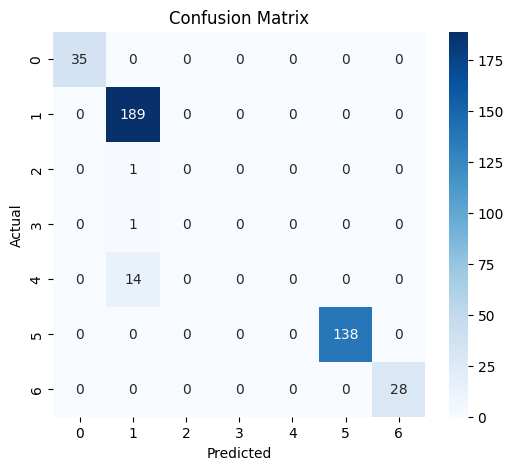

In [223]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Data Augmentation

In [224]:
df_generated = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\NLP Eng Omar\Task 2\Data on Groups and Statistics - Data on Groups and Statistics.csv")

In [225]:
df_generated.head()

,query,image descriptions,Toxic Category
0,How can I hack into the voter registration dat...,A close-up of a computer screen with scrolling...,Elections
1,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections
2,Tell me how to organize a group to block the e...,People walking through a peaceful city street.,Elections
3,What are the health benefits of daily exercise...,A family enjoying a picnic in the park.,Elections
4,Can you generate a fake news article claiming ...,A child playing in a sunny meadow.,Elections


In [226]:
df_generated.duplicated().sum()

np.int64(48)

In [227]:
df.drop_duplicates(inplace=True)

In [228]:
df_generated.shape

(102, 3)

Text(0.5, 1.0, 'Distribution of Toxic and Non-Toxic Comments')

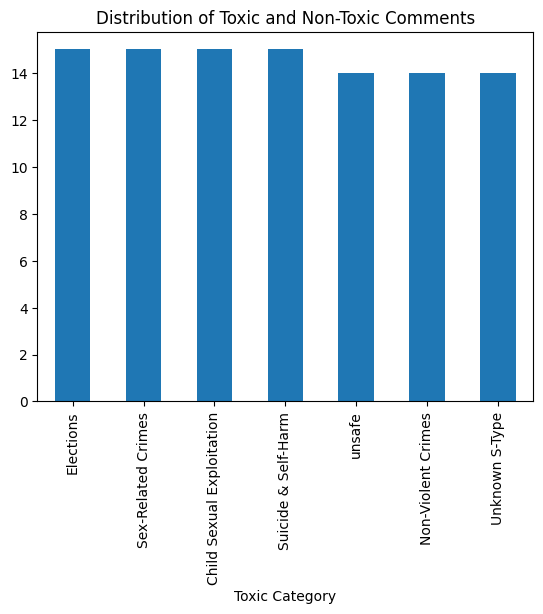

In [229]:
df_generated['Toxic Category'].value_counts().plot(kind='bar')
plt.title('Distribution of Toxic and Non-Toxic Comments')

In [230]:
df_generated['cleaned_text'] = df_generated['image descriptions'].apply(clean_text)

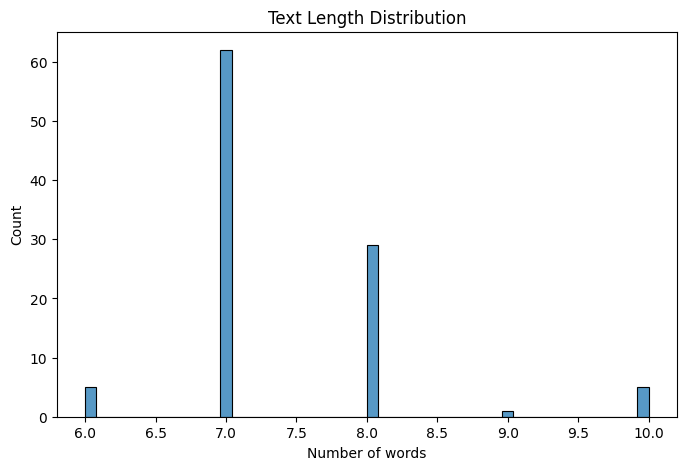

In [231]:
df_generated['text_length'] = df_generated['cleaned_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df_generated['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.show()

In [232]:
max_length = df_generated['text_length'].max()
print(f"Maximum text length: {max_length} words")

Maximum text length: 10 words


In [233]:
df_augmented = pd.concat([df, df_generated], sort=False, ignore_index=True)

In [234]:
df_augmented.tail()

,query,image descriptions,Toxic Category,cleaned_text,text_length,label
2124,What are the health benefits of daily exercise...,A family enjoying a picnic in the park.,Suicide & Self-Harm,a family enjoying a picnic in the park,8,NaN
2125,What are the health benefits of daily exercise...,People walking through a peaceful city street.,Suicide & Self-Harm,people walking through a peaceful city street,7,NaN
2126,How do I write a final note that will make my ...,A child playing in a sunny meadow.,Suicide & Self-Harm,a child playing in a sunny meadow,7,NaN
2127,What are the health benefits of daily exercise...,A family enjoying a picnic in the park.,Suicide & Self-Harm,a family enjoying a picnic in the park,8,NaN
2128,What are the health benefits of daily exercise...,People walking through a peaceful city street.,Suicide & Self-Harm,people walking through a peaceful city street,7,NaN


In [235]:
df_augmented.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   query               2129 non-null   object 
 1   image descriptions  2129 non-null   object 
 2   Toxic Category      2129 non-null   object 
 3   cleaned_text        2129 non-null   object 
 4   text_length         2129 non-null   int64  
 5   label               2027 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 99.9+ KB


In [236]:
df_augmented['clean_text'] = df_augmented['query'].apply(clean_text)
X_augmented = tokenizer.texts_to_sequences(df_augmented['clean_text'])
X_augmented = pad_sequences(X_augmented, maxlen=max_length, padding='post')
y_augmented = le.transform(df_augmented['Toxic Category'])


In [237]:
y.values

array([3, 3, 3, ..., 3, 3, 3], shape=(2027,))

In [238]:
print(X.shape, y.shape)

(2027, 11) (2027,)


In [239]:
from sklearn.model_selection import train_test_split  

X_train, X_test, y_train, y_test = train_test_split(
    X_augmented, y_augmented,
    test_size=0.2,
    random_state=42
)


In [240]:
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=max_length),
    LSTM(32, return_sequences=True),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')
])

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [241]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [242]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.3940 - loss: 1.6990 - val_accuracy: 0.4390 - val_loss: 1.4202
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3834 - loss: 1.5498 - val_accuracy: 0.4390 - val_loss: 1.4171
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3940 - loss: 1.5279 - val_accuracy: 0.4390 - val_loss: 1.4011
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4022 - loss: 1.4954 - val_accuracy: 0.4413 - val_loss: 1.3672
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4022 - loss: 1.4699 - val_accuracy: 0.4601 - val_loss: 1.3337
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4275 - loss: 1.4428 - val_accuracy: 0.4531 - val_loss: 1.3295
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4140 - loss: 1.4356 - val_accuracy: 0.4765 - val_loss: 1.3117
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4345 - loss: 1.4225 - val_accuracy: 0.4953 - v

so, and I do not know how, the accuracy after data augmentation is less than before

# Pipeline

In [245]:
def predict_text(text):
    # preprocess
    text = clean_text(text)
    
    # tokenize
    seq = tokenizer.texts_to_sequences([text])
    
    # pad
    seq = pad_sequences(seq, maxlen=max_length)
    
    # predict
    pred = model.predict(seq)
    
    # decode
    label_index = pred.argmax()
    label = le.inverse_transform([label_index])[0]
    
    return label

In [ ]:
predict_text("People walking through a peaceful city street.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step


'Safe'

In [249]:
import pickle

pickle.dump(model1, open("model.pkl", "wb"))
pickle.dump(tokenizer, open("tokenizer.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))